# Лабораторна робота 4: Багатовимірна класифікація

Три класи в $\mathbb{R}^4$, по 3 навчальні вектори. Тестова точка $\mathbf{t}=(6,6,26,5)$.

**Підхід 1** — середина діапазону: $\mu_{k,j}=\tfrac{1}{2}(\min x_j + \max x_j)$ у класі $k$ (усі точки класу враховуються через min/max).

**Підхід 2** — арифметичне середнє навчальних точок класу.

**Варіант A (голосування):** по кожному виміру $j$ голос отримує клас з $\min_k |t_j-\mu_{k,j}|$.

**Варіант B (зважена сума):** $D_k(\mathbf{t})=\sum_j w_j|t_j-\mu_{k,j}|$, $w_j=1/S_j$, $S_j=\sum_k s_{k,j}$.

In [8]:
from dataclasses import dataclass
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

np.set_printoptions(precision=4, suppress=True)
plt.style.use("seaborn-v0_8-whitegrid")

## Дані та алгоритм

In [9]:
CLASSES: Dict[str, np.ndarray] = {
    "Зелена": np.array([[1, 3, 5, 7], [2, 7, 6, 9], [3, 5, 4, 8]], dtype=float),
    "Синя": np.array([[5, 5, 10, 1], [6, 7, 13, 3], [8, 6, 16, 4]], dtype=float),
    "Червона": np.array([[10, 7, 30, 4], [14, 6, 31, 5], [16, 5, 28, 7]], dtype=float),
}




TEST = np.array([6.0, 6.0, 26.0, 5.0])
CLASS_ORDER = ["Зелена", "Синя", "Червона"]
DIM_LABELS = ["$x_1$", "$x_2$", "$x_3$", "$x_4$"]
CLASS_COLORS = {"Зелена": "#2ca02c", "Синя": "#1f77b4", "Червона": "#d62728"}

def representative_range(points: np.ndarray) -> np.ndarray:
    pts = np.asarray(points, dtype=float)
    return 0.5 * (pts.min(axis=0) + pts.max(axis=0))


def representative_mean(points: np.ndarray) -> np.ndarray:
    return np.asarray(points, dtype=float).mean(axis=0)


def class_spreads(points: np.ndarray) -> np.ndarray:


    pts = np.asarray(points, dtype=float)
    return pts.max(axis=0) - pts.min(axis=0)


def weights_total_spread(classes: Dict[str, np.ndarray]) -> Tuple[np.ndarray, np.ndarray]:
    spreads = {name: class_spreads(pts) for name, pts in classes.items()}
    total = sum(spreads.values())
    return total, 1.0 / total


def build_representatives(classes: Dict[str, np.ndarray], approach: str) -> Dict[str, np.ndarray]:
    fn = representative_range if approach == "range" else representative_mean
    return {name: fn(pts) for name, pts in classes.items()}





@dataclass
class VoteResult:
    votes_per_class: Dict[str, int]
    winners_per_dim: List[List[str]]
    winner: str | None
    tie: bool
    tied_classes: List[str]


def classify_vote(test: np.ndarray, reps: Dict[str, np.ndarray]) -> VoteResult:
    t = np.asarray(test, dtype=float)
    names = list(reps.keys())
    votes = {n: 0 for n in names}
    winners_per_dim: List[List[str]] = []
    for j in range(t.shape[0]):
        dists = {n: abs(t[j] - reps[n][j]) for n in names}
        d_min = min(dists.values())
        winners = [n for n, d in dists.items() if d == d_min]
        winners_per_dim.append(winners)
        for w in winners:
            votes[w] += 1



    max_v = max(votes.values())
    tied = [n for n, v in votes.items() if v == max_v]
    tie = len(tied) > 1
    winner = None if tie else tied[0]
    return VoteResult(votes, winners_per_dim, winner, tie, tied)


@dataclass
class WeightedResult:
    distances: Dict[str, float]
    winner: str


def classify_weighted(test: np.ndarray, reps: Dict[str, np.ndarray], weights: np.ndarray) -> WeightedResult:
    t = np.asarray(test, dtype=float)
    w = np.asarray(weights, dtype=float)
    dists = {n: float(np.sum(w * np.abs(t - reps[n]))) for n in reps}
    return WeightedResult(dists, min(dists, key=dists.get))


def run_experiment(classes=None, test=None) -> dict:
    classes = classes or CLASSES
    test = test if test is not None else TEST
    names = [n for n in CLASS_ORDER if n in classes]
    total_spread, weights = weights_total_spread(classes)
    spreads = {n: class_spreads(classes[n]) for n in names}
    results = {}
    for approach in ("range", "mean"):
        reps = build_representatives(classes, approach)
        results[approach] = {
            "representatives": reps,
            "vote": classify_vote(test, reps),
            "weighted": classify_weighted(test, reps, weights),
        }
    return {
        "classes": classes,
        "test": test,
        "names": names,
        "spreads": spreads,
        "total_spread": total_spread,
        "weights": weights,
        "range": results["range"],
        "mean": results["mean"],
    }

## Вихідні дані

In [10]:
for name in CLASS_ORDER:
    print(f"{name}:")
    display(pd.DataFrame(CLASSES[name], columns=[f"x{i+1}" for i in range(4)], index=range(1, 4)))
print("Тест:", TEST)

Зелена:


,x1,x2,x3,x4
1,1.0,3.0,5.0,7.0
2,2.0,7.0,6.0,9.0
3,3.0,5.0,4.0,8.0


Синя:


,x1,x2,x3,x4
1,5.0,5.0,10.0,1.0
2,6.0,7.0,13.0,3.0
3,8.0,6.0,16.0,4.0


Червона:


,x1,x2,x3,x4
1,10.0,7.0,30.0,4.0
2,14.0,6.0,31.0,5.0
3,16.0,5.0,28.0,7.0


Тест: [ 6.  6. 26.  5.]


## Обчислення та класифікація

In [11]:
exp = run_experiment()

for n in CLASS_ORDER:
    print(f"{n}: підхід 1 = {exp['range']['representatives'][n]}, підхід 2 = {exp['mean']['representatives'][n]}")

spread_rows = []
for j, lab in enumerate(DIM_LABELS):
    row = {"Вимір": lab}
    for n in CLASS_ORDER:
        row[n] = exp["spreads"][n][j]
    row["S_j"] = exp["total_spread"][j]
    row["w_j"] = exp["weights"][j]
    spread_rows.append(row)
display(pd.DataFrame(spread_rows))

for approach_key, title in [("range", "Підхід 1"), ("mean", "Підхід 2")]:
    vote = exp[approach_key]["vote"]
    wd = exp[approach_key]["weighted"]
    print(f"\n=== {title} ===")
    print("Голоси:", vote.votes_per_class)
    if vote.tie:
        print("Голосування: нічия", vote.tied_classes)
    else:
        print("Голосування:", vote.winner)
    print("D_k:", {k: round(v, 4) for k, v in wd.distances.items()})
    print("Зважене:", wd.winner)

Зелена: підхід 1 = [2. 5. 5. 8.], підхід 2 = [2. 5. 5. 8.]
Синя: підхід 1 = [ 6.5  6.  13.   2.5], підхід 2 = [ 6.3333  6.     13.      2.6667]
Червона: підхід 1 = [13.   6.  29.5  5.5], підхід 2 = [13.3333  6.     29.6667  5.3333]


,Вимір,Зелена,Синя,Червона,S_j,w_j
0,$x_1$,2.0,3.0,6.0,11.0,0.090909
1,$x_2$,4.0,2.0,2.0,8.0,0.125000
2,$x_3$,2.0,6.0,3.0,11.0,0.090909
3,$x_4$,2.0,3.0,3.0,8.0,0.125000



=== Підхід 1 ===
Голоси: {'Зелена': 0, 'Синя': 2, 'Червона': 3}
Голосування: Червона
D_k: {'Зелена': 2.7727, 'Синя': 1.5398, 'Червона': 1.017}
Зважене: Червона

=== Підхід 2 ===
Голоси: {'Зелена': 0, 'Синя': 2, 'Червона': 3}
Голосування: Червона
D_k: {'Зелена': 2.7727, 'Синя': 1.5038, 'Червона': 1.0417}
Зважене: Червона


## Візуалізації

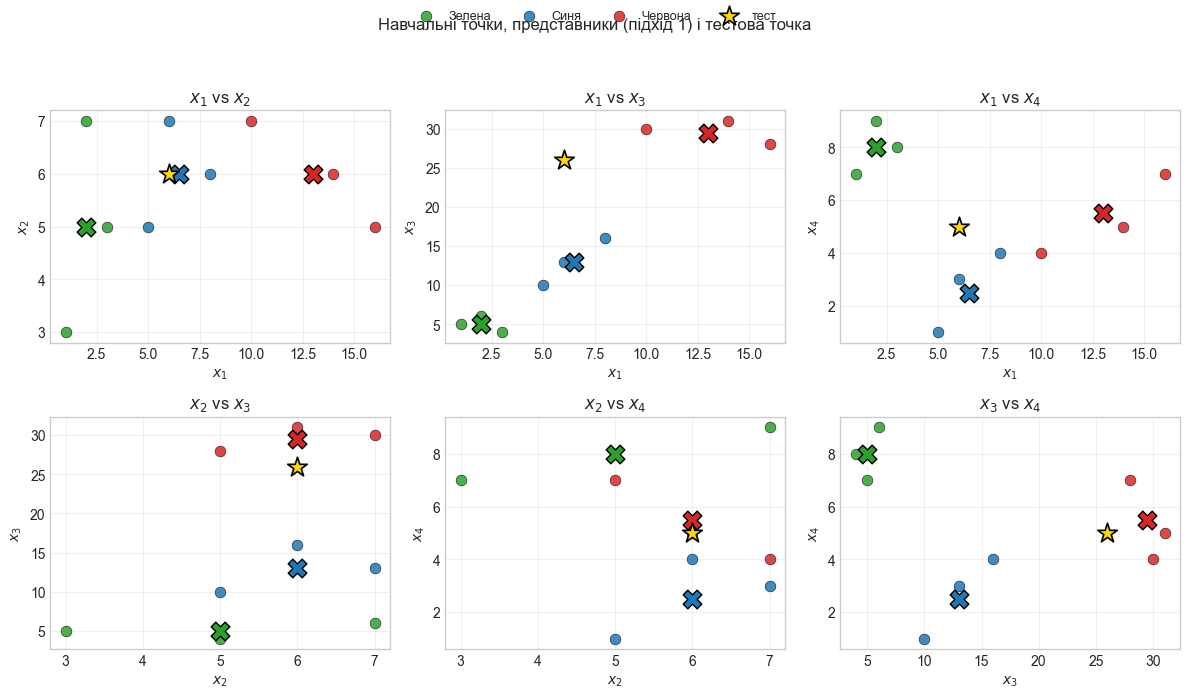

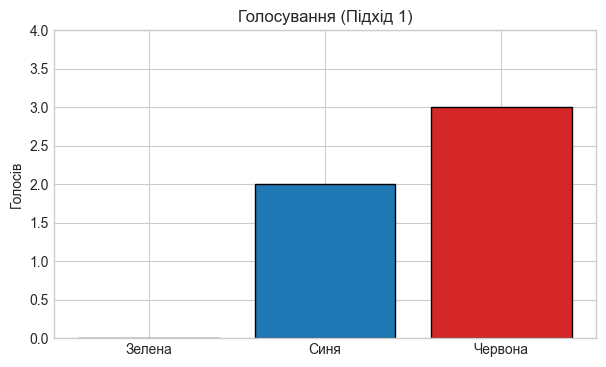

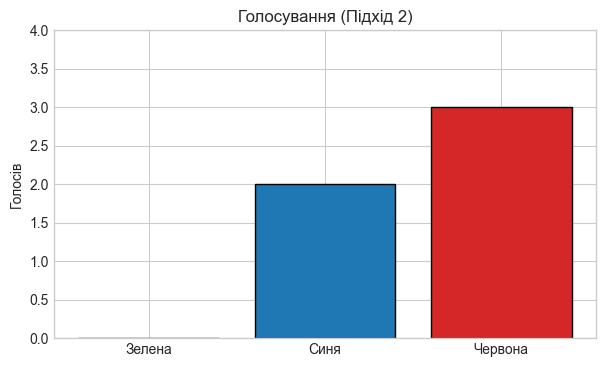

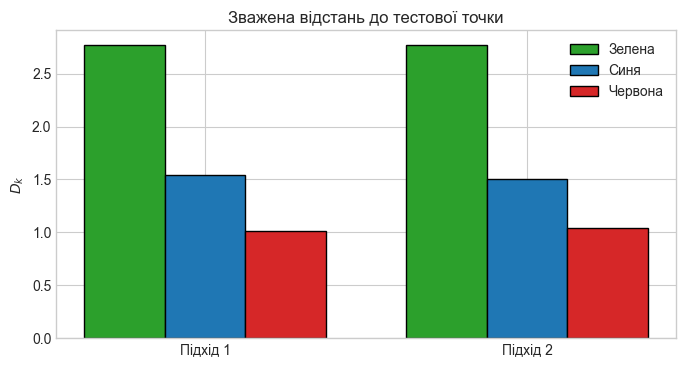

In [12]:
from pathlib import Path

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)
classes = exp["classes"]
test = exp["test"]
names = exp["names"]
pairs = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
reps_r = exp["range"]["representatives"]

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, (i, j) in zip(axes.ravel(), pairs):
    for n in names:
        pts = classes[n]
        ax.scatter(pts[:, i], pts[:, j], c=CLASS_COLORS[n], s=60, alpha=0.85, label=n, edgecolors="k", linewidths=0.4)
        mu = reps_r[n]
        ax.scatter(mu[i], mu[j], c=CLASS_COLORS[n], s=180, marker="X", edgecolors="black", linewidths=1.0, zorder=5)
    ax.scatter(test[i], test[j], s=220, c="gold", marker="*", edgecolors="black", linewidths=1.2, zorder=6, label="тест")
    ax.set_xlabel(f"$x_{i+1}$")
    ax.set_ylabel(f"$x_{j+1}$")
    ax.set_title(f"$x_{i+1}$ vs $x_{j+1}$")
    ax.grid(True, alpha=0.3)
handles, labels = axes[0, 0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys(), loc="upper center", ncol=4, fontsize=9)
fig.suptitle("Навчальні точки, представники (підхід 1) і тестова точка")
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

for approach_key, title in [("range", "Підхід 1"), ("mean", "Підхід 2")]:
    vote = exp[approach_key]["vote"]
    fig, ax = plt.subplots(figsize=(7, 4))
    counts = [vote.votes_per_class[n] for n in names]
    ax.bar(names, counts, color=[CLASS_COLORS[n] for n in names], edgecolor="black")
    ax.set_ylabel("Голосів")
    ax.set_title(f"Голосування ({title})")
    ax.set_ylim(0, max(counts) + 1)
    plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(2)
width = 0.25
for idx, n in enumerate(names):
    vals = [exp["range"]["weighted"].distances[n], exp["mean"]["weighted"].distances[n]]
    ax.bar(x + idx * width, vals, width, label=n, color=CLASS_COLORS[n], edgecolor="black")
ax.set_xticks(x + width)
ax.set_xticklabels(["Підхід 1", "Підхід 2"])
ax.set_ylabel(r"$D_k$")
ax.set_title("Зважена відстань до тестової точки")
ax.legend()
plt.show()